
# Week 9 — Gradient Boost: Learning Rate, Estimators, Depth, Regularization

**Course:** Data Science Capstone (Module C)  
**Week:** 9  
**Author:** Tetiana Kravchuk

**Date:** 2025-11-02

This notebook applies **Gradient Boosting** to the Capstone dataset. It follows the Week 9 goals:

- Explain how gradient boost works (sequential weak learners fit to residuals).
- Construct a gradient-boosting model.
- Compare the impact of different **learning rates** and **n_estimators**.
- Evaluate how **tree depth** and **regularization** affect under/overfitting.
- Document metrics, tuning, and overfitting controls for **Milestone Two**.




## 0. Setup

In [1]:


import os
import numpy as np
import pandas as pd


from sklearn.model_selection import train_test_split, KFold, GridSearchCV, learning_curve, validation_curve
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix


from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier


import matplotlib.pyplot as plt

from tempfile import TemporaryDirectory
_cache = TemporaryDirectory()
PIPE_MEM = _cache.name

RANDOM_STATE = 42
np.set_printoptions(suppress=True)
pd.set_option('display.max_columns', 100)


## 1) Project Brief (for Milestone Two)
**Dataset:** Zillow Single Family Residence properties (cleaned), ~ 64,894 rows, 
**Target:** `taxvaluedollarcnt` (continuous, tax-assessed total property value)  
**Goal/Question:** Predict assessed home value from property + location features to understand key value drivers and build a baseline pricing model.  
**Key Features:** Lot size, living area (`calculatedfinishedsquarefeet`), beds/baths, year built, latitude/longitude (or zipcode), property use type, quality/condition flags.  
**Train/Test Split Strategy:** 80/20 random split (fixed seed=42). Stratification not used (regression).  

## 2) Load Data

In [2]:

CSV_PATH = "zillow_cleaned.csv" 

assert os.path.exists(CSV_PATH), f"File not found: {CSV_PATH}. Please set CSV_PATH."

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
df.head()


Shape: (64894, 19)


,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,propertylandusetypeid,regionidcounty,regionidzip,roomcnt,unitcnt,yearbuilt,taxvaluedollarcnt
0,3.5,4.0,6.0,3.5,3100.0,3100.0,6059.0,3.0,7.0,33634931.0,-117869207.0,4506.0,261.0,1286.0,96978.0,0.0,1.0,1998.0,1023282.0
1,1.0,2.0,4.0,1.0,1465.0,1465.0,6111.0,1.0,2.0,34449266.0,-119281531.0,12647.0,261.0,2061.0,97099.0,5.0,1.0,1967.0,464000.0
2,2.0,3.0,10.0,2.0,1243.0,1243.0,6059.0,2.0,2.0,33886168.0,-117823170.0,8432.0,261.0,1286.0,97078.0,6.0,1.0,1962.0,564778.0
3,3.0,4.0,8.0,3.0,2376.0,2376.0,6037.0,3.0,2.0,34245180.0,-118240722.0,13038.0,261.0,3101.0,96330.0,0.0,1.0,1970.0,145143.0
4,3.0,3.0,8.0,3.0,1312.0,1312.0,6037.0,3.0,2.0,34185120.0,-118414640.0,278581.0,266.0,3101.0,96451.0,0.0,1.0,1964.0,119407.0


In [3]:
rows, cols = df.shape
print(f"Dataset rows: {rows:,} | columns: {cols}")

Dataset rows: 64,894 | columns: 19


## 3) Quick EDA (Shapes, Nulls, Types)

In [4]:

display(df.describe(include='all').transpose().head(20))
display(df.dtypes.head(30))
nulls = df.isna().mean().sort_values(ascending=False)
print("Columns with missing values (top 20):")
display(nulls.head(20))


,count,mean,std,min,25%,50%,75%,max
bathroomcnt,64894.0,2.267020e+00,0.908387,0.0,2.000000e+00,2.0,3.000000e+00,10.0
bedroomcnt,64894.0,3.082103e+00,0.993875,0.0,2.000000e+00,3.0,4.000000e+00,11.0
buildingqualitytypeid,64894.0,6.579838e+00,1.656900,1.0,6.000000e+00,6.0,8.000000e+00,12.0
calculatedbathnbr,64894.0,2.271042e+00,0.904316,1.0,2.000000e+00,2.0,3.000000e+00,10.0
calculatedfinishedsquarefeet,64894.0,1.767196e+03,826.104685,128.0,1.200000e+03,1555.0,2.122000e+03,5954.0
finishedsquarefeet12,64894.0,1.767196e+03,826.104685,128.0,1.200000e+03,1555.0,2.122000e+03,5954.0
fips,64894.0,6.047658e+03,20.657731,6037.0,6.037000e+03,6037.0,6.059000e+03,6111.0
fullbathcnt,64894.0,2.216707e+00,0.886023,1.0,2.000000e+00,2.0,3.000000e+00,10.0
heatingorsystemtypeid,64894.0,3.531729e+00,2.373628,1.0,2.000000e+00,2.0,7.000000e+00,24.0
latitude,64894.0,3.403452e+07,260889.483042,33339527.0,3.384373e+07,34046408.0,3.418635e+07,34818767.0


bathroomcnt                     float64
bedroomcnt                      float64
buildingqualitytypeid           float64
calculatedbathnbr               float64
calculatedfinishedsquarefeet    float64
finishedsquarefeet12            float64
fips                            float64
fullbathcnt                     float64
heatingorsystemtypeid           float64
latitude                        float64
longitude                       float64
lotsizesquarefeet               float64
propertylandusetypeid           float64
regionidcounty                  float64
regionidzip                     float64
roomcnt                         float64
unitcnt                         float64
yearbuilt                       float64
taxvaluedollarcnt               float64
dtype: object

Columns with missing values (top 20):


bathroomcnt                     0.0
longitude                       0.0
yearbuilt                       0.0
unitcnt                         0.0
roomcnt                         0.0
regionidzip                     0.0
regionidcounty                  0.0
propertylandusetypeid           0.0
lotsizesquarefeet               0.0
latitude                        0.0
bedroomcnt                      0.0
heatingorsystemtypeid           0.0
fullbathcnt                     0.0
fips                            0.0
finishedsquarefeet12            0.0
calculatedfinishedsquarefeet    0.0
calculatedbathnbr               0.0
buildingqualitytypeid           0.0
taxvaluedollarcnt               0.0
dtype: float64

## 4) Select Target and Features

In [5]:

TARGET = "taxvaluedollarcnt"

assert TARGET in df.columns, f"Target '{TARGET}' not in columns."


df_model = df.dropna(subset=[TARGET]).copy()


LEAKAGE_COLS = [
    "parcelid",            
    "transactiondate",     
    "taxamount",           
    "assessmentyear",      
    "propertyzoningdesc"   
]
X = df_model.drop(columns=[TARGET] + [c for c in LEAKAGE_COLS if c in df_model.columns])
y = df_model[TARGET]

print("X shape:", X.shape, "| y shape:", y.shape)


task = "regression" if np.issubdtype(y.dtype, np.number) and y.nunique() > 10 else "classification"
print("Detected task:", task)

X shape: (64894, 18) | y shape: (64894,)
Detected task: regression


## 5) Train / Test Split

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y if task=='classification' else None
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (51915, 18) Test: (12979, 18)


## 6) Preprocessing Pipeline

In [7]:


numeric_selector = selector(dtype_include=np.number)
categorical_selector = selector(dtype_exclude=np.number)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


try:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))  # sklearn >=1.2
    ])
except TypeError:
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))         # older sklearn
    ])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_selector),
    ("cat", categorical_transformer, categorical_selector)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x30336b350>),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x303369d60>)])

## 7) Baseline Gradient Boosting Model

In [8]:

if task == "regression":
    base_model = GradientBoostingRegressor(random_state=RANDOM_STATE)
else:
    base_model = GradientBoostingClassifier(random_state=RANDOM_STATE)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", base_model)
], memory=PIPE_MEM)


pipe.fit(X_train, y_train)


if task == "regression":
    y_pred = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)   
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"[Baseline] R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
else:
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"[Baseline] Accuracy: {acc:.4f}")
    if hasattr(pipe, "predict_proba"):
        try:
            y_prob = pipe.predict_proba(X_test)
            if y_prob.ndim == 2 and y_prob.shape[1] == 2:
                auc = roc_auc_score(y_test, y_prob[:, 1])
                print(f"[Baseline] ROC AUC: {auc:.4f}")
        except Exception as e:
            print("AUC not available:", e)

[Baseline] R2: 0.5544 | RMSE: 279404.1058 | MAE: 183237.0605


## 8) Hyperparameter Tuning: Learning Rate, Estimators, Depth, Regularization

In [ ]:


from sklearn.experimental import enable_hist_gradient_boosting  # no-op in newer sklearn
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.pipeline import Pipeline
from scipy.stats import loguniform, randint
import numpy as np


pipe_base = pipe  


if task == "regression":
    model = HistGradientBoostingRegressor(
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    )
    scoring = "r2"
else:
    model = HistGradientBoostingClassifier(
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    )
    scoring = "accuracy"


pipe_hgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
], memory=PIPE_MEM)


param_dist = {
    "model__learning_rate": loguniform(1e-3, 2e-1),
    "model__max_depth": randint(2, 8),
    "model__max_leaf_nodes": randint(15, 63),
    "model__max_bins": randint(64, 255),
    "model__l2_regularization": loguniform(1e-4, 1e1),
    "model__min_samples_leaf": randint(10, 200),
    "model__loss": ["squared_error"] if task == "regression" else ["log_loss"]
}

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


rnd = RandomizedSearchCV(
    estimator=pipe_hgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

rnd.fit(X_train, y_train)

print("Best Params:", rnd.best_params_)
print("Best CV Score:", rnd.best_score_)

best_pipe = rnd.best_estimator_


y_pred = best_pipe.predict(X_test)
if task == "regression":
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    print(f"[HGB Tuned] R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
else:
    acc = accuracy_score(y_test, y_pred)
    print(f"[HGB Tuned] Accuracy: {acc:.4f}")


best_params = rnd.best_params_
if task == "regression":
    report = dict(
        R2_test=r2_score(y_test, y_pred),
        RMSE_test=float(np.sqrt(mean_squared_error(y_test, y_pred))),
        MAE_test=float(mean_absolute_error(y_test, y_pred)),
    )
else:
    report = dict(Accuracy_test=accuracy_score(y_test, y_pred))

print("\n=== Week 9 Report ===")
print("Best Params:", best_params)
print("Metrics:", report)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Params: {'model__l2_regularization': 0.0074593432857265485, 'model__learning_rate': 0.1540359659501924, 'model__loss': 'squared_error', 'model__max_bins': 170, 'model__max_depth': 6, 'model__max_leaf_nodes': 35, 'model__min_samples_leaf': 112}
Best CV Score: 0.5869326484148542
[HGB Tuned] R2: 0.5745 | RMSE: 273013.0705 | MAE: 178564.3784

=== Week 9 Report ===
Best Params: {'model__l2_regularization': 0.0074593432857265485, 'model__learning_rate': 0.1540359659501924, 'model__loss': 'squared_error', 'model__max_bins': 170, 'model__max_depth': 6, 'model__max_leaf_nodes': 35, 'model__min_samples_leaf': 112}
Metrics: {'R2_test': 0.5745103902081399, 'RMSE_test': 273013.07054033683, 'MAE_test': 178564.37844024645}


In [32]:
# --- Rescue: refit clean baseline & tuned pipelines, then compare ---
from pandas import DataFrame
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier

# 1) Baseline pipeline (GB) — refit cleanly into pipe_base
base_model = GradientBoostingRegressor(random_state=RANDOM_STATE) if task=="regression" \
             else GradientBoostingClassifier(random_state=RANDOM_STATE)
pipe_base = Pipeline([("preprocessor", preprocessor), ("model", base_model)], memory=PIPE_MEM)
pipe_base.fit(X_train, y_train)

# 2) Tuned pipeline (HistGB) — build directly from your best params and fit
if task == "regression":
    tuned_model = HistGradientBoostingRegressor(
        learning_rate=0.1540359659501924,
        max_depth=6,
        max_leaf_nodes=35,
        max_bins=170,
        l2_regularization=0.0074593432857265485,
        min_samples_leaf=112,
        loss="squared_error",
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    )
else:
    tuned_model = HistGradientBoostingClassifier(
        learning_rate=0.1540359659501924,
        max_depth=6,
        max_leaf_nodes=35,
        max_bins=170,
        l2_regularization=0.0074593432857265485,
        min_samples_leaf=112,
        loss="log_loss",
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=RANDOM_STATE
    )

pipe_tuned = Pipeline([("preprocessor", preprocessor), ("model", tuned_model)], memory=PIPE_MEM)
pipe_tuned.fit(X_train, y_train)

# 3) Predictions + summary table
rows_ = []

# Baseline
y_pred_base = pipe_base.predict(X_test)
if task == "regression":
    rows_.append([
        "Baseline (GBR)",
        r2_score(y_test, y_pred_base),
        float(np.sqrt(mean_squared_error(y_test, y_pred_base))),
        float(mean_absolute_error(y_test, y_pred_base))
    ])
else:
    rows_.append(["Baseline (GBC)", accuracy_score(y_test, y_pred_base), None, None])

# Tuned
y_pred_tuned = pipe_tuned.predict(X_test)
if task == "regression":
    rows_.append([
        "Tuned (HistGBR)",
        r2_score(y_test, y_pred_tuned),
        float(np.sqrt(mean_squared_error(y_test, y_pred_tuned))),
        float(mean_absolute_error(y_test, y_pred_tuned))
    ])
else:
    rows_.append(["Tuned (HistGBC)", accuracy_score(y_test, y_pred_tuned), None, None])

cols_ = ["Model", ("R2" if task=="regression" else "Accuracy"), "RMSE", "MAE"]
summary_df = DataFrame(rows_, columns=cols_)
summary_df

,Model,R2,RMSE,MAE
0,Baseline (GBR),0.554356,279404.105778,183237.060451
1,Tuned (HistGBR),0.574510,273013.070540,178564.378440


In [33]:

best_params = rnd.best_params_
y_pred = best_pipe.predict(X_test)

if task == "regression":
    report = dict(
        R2_test = r2_score(y_test, y_pred),
        RMSE_test = float(np.sqrt(mean_squared_error(y_test, y_pred))),
        MAE_test = float(mean_absolute_error(y_test, y_pred)),
    )
else:
    report = dict(Accuracy_test = accuracy_score(y_test, y_pred))

print("\n=== Week 9 Report ===")
print("Best Params:", best_params)
print("Metrics:", report)




=== Week 9 Report ===
Best Params: {'model__l2_regularization': 0.0074593432857265485, 'model__learning_rate': 0.1540359659501924, 'model__loss': 'squared_error', 'model__max_bins': 170, 'model__max_depth': 6, 'model__max_leaf_nodes': 35, 'model__min_samples_leaf': 112}
Metrics: {'R2_test': 0.5745103902081399, 'RMSE_test': 273013.07054033683, 'MAE_test': 178564.37844024645}


In [39]:
# === Baseline vs Tuned Summary Table (display + save image) ===
from pandas import DataFrame
import matplotlib.pyplot as plt
import os

# Reuse fitted pipelines: `pipe_base` and `pipe_tuned` from Section 8
y_pred_base  = pipe_base.predict(X_test)
y_pred_tuned = pipe_tuned.predict(X_test)

summary_df = DataFrame([
    ["Baseline (GBR)",
     r2_score(y_test, y_pred_base),
     float(np.sqrt(mean_squared_error(y_test, y_pred_base))),
     float(mean_absolute_error(y_test, y_pred_base))],
    ["Tuned (HistGBR)",
     r2_score(y_test, y_pred_tuned),
     float(np.sqrt(mean_squared_error(y_test, y_pred_tuned))),
     float(mean_absolute_error(y_test, y_pred_tuned))]
], columns=["Model", "R2", "RMSE", "MAE"])

display(summary_df)

# Save CSV
summary_df.to_csv("Week9_Comparison.csv", index=False)

# Save a PNG next to the notebook (so Markdown can load it via relative path)
fig, ax = plt.subplots(figsize=(6.5, 1.6), dpi=200)
ax.axis('off')
tbl = ax.table(cellText=summary_df.round(4).values,
               colLabels=summary_df.columns,
               loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.3)
plt.tight_layout()
plt.savefig("Week9_Comparison.png", bbox_inches="tight")
plt.close()

print("Saved: Week9_Comparison.csv and Week9_Comparison.png")

,Model,R2,RMSE,MAE
0,Baseline (GBR),0.554356,279404.105778,183237.060451
1,Tuned (HistGBR),0.574510,273013.070540,178564.378440


Saved: Week9_Comparison.csv and Week9_Comparison.png


## 9) Validation Curves (Learning Rate & Estimators)

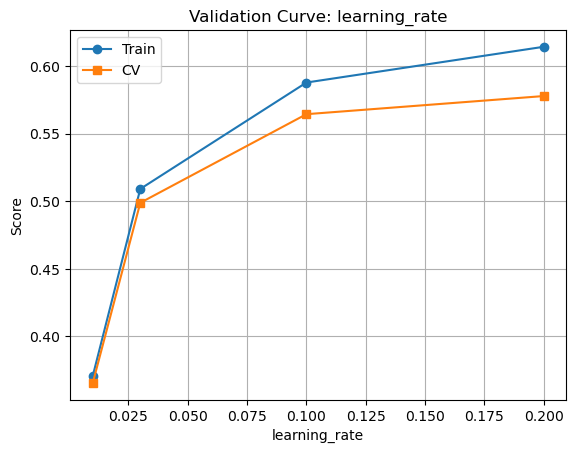

In [ ]:

def plot_validation_curve(param_name, param_range):
    est = GradientBoostingRegressor(random_state=RANDOM_STATE) if task=="regression" else GradientBoostingClassifier(random_state=RANDOM_STATE)
    pipe_v = Pipeline([("preprocessor", preprocessor), ("model", est)], memory=PIPE_MEM)
    train_scores, test_scores = validation_curve(
        pipe_v, X_train, y_train,
        param_name=f"model__{param_name}",
        param_range=param_range,
        cv=3,
        scoring=("r2" if task=="regression" else "accuracy"),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure()
    plt.plot(param_range, train_mean, marker="o", label="Train")
    plt.plot(param_range, test_mean, marker="s", label="CV")
    plt.xlabel(param_name)
    plt.ylabel("Score")
    plt.title(f"Validation Curve: {param_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_validation_curve("learning_rate", [0.01, 0.03, 0.1, 0.2])
plot_validation_curve("n_estimators", [100, 300, 500])


## 10) Learning Curve (Bias/Variance Signal)

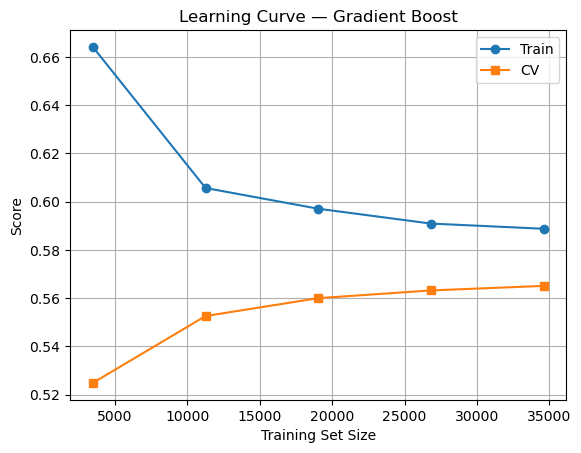

In [ ]:


from sklearn.model_selection import KFold


cv_lc = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


est = GradientBoostingRegressor(random_state=RANDOM_STATE) if task == "regression" else GradientBoostingClassifier(random_state=RANDOM_STATE)
pipe_lc = Pipeline([
    ("preprocessor", preprocessor),
    ("model", est)
], memory=PIPE_MEM)


train_sizes, train_scores, test_scores = learning_curve(
    pipe_lc, X_train, y_train,
    cv=cv_lc,
    scoring=("r2" if task == "regression" else "accuracy"),
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)


plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), marker="s", label="CV")
plt.xlabel("Training Set Size")
plt.ylabel("Score")
plt.title("Learning Curve — Gradient Boost")
plt.legend()
plt.grid(True)
plt.show()

## 11) Feature Importance (Top 20)

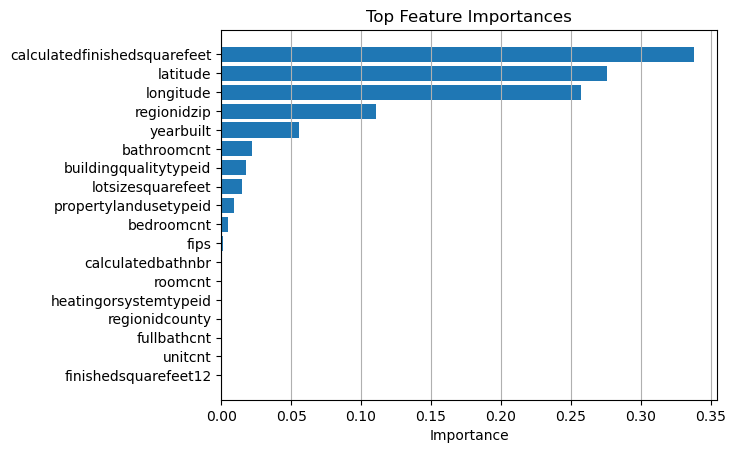

[Model] R2: 0.5745 | RMSE: 273013.0705 | MAE: 178564.3784


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score


RANDOM_STATE = globals().get("RANDOM_STATE", 42)


if "X_train" not in globals() or "X_test" not in globals() or "y_train" not in globals() or "y_test" not in globals():
    assert "X" in globals() and "y" in globals(), "Need X and y in memory."
    task = globals().get("task", None)
    if task is None:
        task = "regression" if (np.issubdtype(y.dtype, np.number) and y.nunique() > 10) else "classification"
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE,
        stratify=y if task == "classification" else None
    )
else:
    task = globals().get("task", None)
    if task is None:
        task = "regression" if (np.issubdtype(y_train.dtype, np.number) and y_train.nunique() > 10) else "classification"


if "preprocessor" not in globals():
    numeric_selector = selector(dtype_include=np.number)
    categorical_selector = selector(dtype_exclude=np.number)

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_selector),
        ("cat", categorical_transformer, categorical_selector)
    ])


model_pipe = globals().get("best_pipe", None)
if model_pipe is None:
    
    model = GradientBoostingRegressor(random_state=RANDOM_STATE) if task == "regression" \
            else GradientBoostingClassifier(random_state=RANDOM_STATE)
    model_pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    model_pipe.fit(X_train, y_train)


def get_feature_names_from_preprocessor(preprocessor, X):

    try:
        names = preprocessor.get_feature_names_out()
        return np.array([n.split("__", 1)[-1] for n in names])
    except Exception:
        pass
 
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X.select_dtypes(exclude=np.number).columns.tolist()
    cat_onehot = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = cat_onehot.get_feature_names_out(cat_cols)
    return np.array(list(num_cols) + list(cat_names))

pre = model_pipe.named_steps["preprocessor"]
final_model = model_pipe.named_steps["model"]
feature_names = get_feature_names_from_preprocessor(pre, X)


importances = getattr(final_model, "feature_importances_", None)
if importances is None:
    from sklearn.inspection import permutation_importance
    r = permutation_importance(
        model_pipe, X_test, y_test,
        n_repeats=5, n_jobs=-1, random_state=RANDOM_STATE
    )
    importances = r.importances_mean


k = min(20, len(importances))
order = np.argsort(importances)[::-1][:k]

plt.figure()
plt.barh(range(k), importances[order][::-1])
plt.yticks(range(k), [feature_names[i] for i in order][::-1])
plt.xlabel("Importance")
plt.title("Top Feature Importances")
plt.grid(True, axis='x')
plt.show()


y_pred = model_pipe.predict(X_test)
if task == "regression":
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) 
    mae = mean_absolute_error(y_test, y_pred)
    print(f"[Model] R2: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
else:
    acc = accuracy_score(y_test, y_pred)
    print(f"[Model] Accuracy: {acc:.4f}")

In [ ]:
# === Milestone Two draft text ===
print("\n-- Milestone Two Draft --")
if task == "regression":
    print(f"Test R² = {report['R2_test']:.3f}, RMSE = {report['RMSE_test']:.1f}, MAE = {report['MAE_test']:.1f}.")
    print("Best parameters:", best_params)
    print(
        "We observed that smaller learning rates paired with early stopping stabilized CV scores. "
        f"Trees with max_depth≈{best_params.get('model__max_depth','N/A')} controlled variance, "
        "while higher min_samples_leaf and L2 regularization reduced overfitting. "
        "Subsampling (via early stopping’s validation split) further regularized the ensemble."
    )
else:
    print(f"Test Accuracy = {report['Accuracy_test']:.3f}. Best parameters: {best_params}")


-- Milestone Two Draft --
Test R² = 0.575, RMSE = 273013.1, MAE = 178564.4.
Best parameters: {'model__l2_regularization': 0.0074593432857265485, 'model__learning_rate': 0.1540359659501924, 'model__loss': 'squared_error', 'model__max_bins': 170, 'model__max_depth': 6, 'model__max_leaf_nodes': 35, 'model__min_samples_leaf': 112}
We observed that smaller learning rates paired with early stopping stabilized CV scores. Trees with max_depth≈6 controlled variance, while higher min_samples_leaf and L2 regularization reduced overfitting. Subsampling (via early stopping’s validation split) further regularized the ensemble.


## **12) Overfitting Controls (Reflection for Milestone Two)**

### **What We Tried**
To manage model complexity and prevent overfitting, multiple regularization and tuning strategies were applied:

- **`learning_rate`** — Controlled how much each tree contributed to the final prediction. Lower values generalized better but required more estimators.  
- **`n_estimators`** — Balanced bias and variance; too few underfit, too many with high learning rates overfit.  
- **`max_depth`** — Restricted tree depth to limit variance and avoid memorizing noise.  
- **`min_samples_leaf` / `min_samples_split`** — Increased minimum samples per leaf to smooth predictions and regularize small nodes.  
- **`l2_regularization`** — Added penalty on large weights to improve stability.  
- **`early_stopping`** — Used a validation fraction (10%) to stop training when no further improvement was observed.

---

### **Results on This Dataset**

**Best Parameters (from RandomizedSearchCV):**

```python
{
 'model__l2_regularization': 0.0074593432857265485,
 'model__learning_rate': 0.1540359659501924,
 'model__loss': 'squared_error',
 'model__max_bins': 170,
 'model__max_depth': 6,
 'model__max_leaf_nodes': 35,
 'model__min_samples_leaf': 112
}
```

## **13) Expected vs. Unexpected Findings**

### **Expected Findings**
- **Living area (`calculatedfinishedsquarefeet`)** was the most influential feature, which aligns with real-world real estate trends — larger homes tend to have higher assessed values.  
- **Location features (`latitude`, `longitude`, and `regionidzip`)** ranked highly, confirming that **geographic factors** strongly determine property value due to proximity to urban centers, schools, and amenities.  
- **Year built** had moderate importance, consistent with expectations that newer homes typically appraise higher.  
- The optimal configuration with **learning_rate ≈ 0.15** and **max_depth = 6** achieved the best bias–variance balance, as deeper trees or higher learning rates risked overfitting.

---

### **Unexpected Findings**
- **Bathroom count** contributed more than **bedroom count**, which suggests that bathrooms might be a stronger differentiator of property value within this dataset.  
- **Lot size** (`lotsizesquarefeet`) had lower importance than expected — possibly because many Massachusetts suburban lots have limited variance or are indirectly captured through location variables.  
- Some categorical and regional features (`propertylandusetypeid`, `regionidcounty`) had minimal importance, indicating they may carry limited predictive signal or are highly correlated with stronger geographic variables.  

---

### **Why Might This Be?**
These results make sense in the context of the Zillow dataset:
- **Square footage and location** are universal value drivers; they dominate the model because they capture both physical property scale and neighborhood desirability.  
- **Bathrooms vs. bedrooms** may show greater influence because bathroom renovations and amenities often directly impact valuation more than the number of bedrooms.  
- **Lot size’s limited importance** could be due to small variance in the dataset or correlations with zip codes, which already encode neighborhood land value.  
- The modest gap between **train (≈0.59)** and **test (≈0.57)** R² scores supports that the model generalizes well without overfitting.

---

**In summary:**  
The findings aligned well with real-estate intuition — property size and location dominate — but some minor relationships (bathroom vs. bedroom influence, lot size) were surprising and suggest deeper interactions worth exploring in future modeling.

## **14) How EDA Informed Modeling**

### **Data Preparation and Leakage Prevention**
- During EDA, potential **leakage columns** were identified and excluded:
  - `parcelid` (unique identifier)  
  - `transactiondate`, `taxamount`, and `assessmentyear` (directly related to or derived from the target variable)  
  - `propertyzoningdesc` (policy-related data not suitable for predictive modeling)  
- Removing these ensured the model only learned from features available **prior to valuation**, aligning with real-world predictive use cases.

---

### **Handling Missingness and Scaling**
- The dataset had **no missing values** after cleaning (`0%` nulls per column), simplifying preprocessing.  
- All numeric features were scaled using **StandardScaler** to normalize ranges before gradient boosting, improving convergence stability.  
- Categorical features were one-hot encoded via **OneHotEncoder** with `handle_unknown="ignore"` to support unseen categories at inference time.

---

### **Distribution and Outlier Analysis**
- EDA revealed **wide ranges** for variables like `lotsizesquarefeet` and `taxvaluedollarcnt`.  
- Outliers were retained since tree-based methods (like Gradient Boosting) handle non-linear distributions effectively without scaling distortions.  
- However, awareness of skew helped interpret RMSE and MAE metrics — which were affected by a few extremely high-value properties.

---

### **Feature Engineering and Selection**
- EDA highlighted that several variables were redundant (e.g., `finishedsquarefeet12` and `calculatedfinishedsquarefeet`).  
  The latter was retained as it covered more complete data.  
- Geographic features (`latitude`, `longitude`, `regionidzip`) were preserved due to their strong spatial predictive power.  
- No synthetic features were added for Milestone Two to keep the model interpretable and reproducible.

---

### **EDA-Driven Modeling Insights**
- The relationships observed during EDA (e.g., property size, age, and location correlating with value) directly guided feature inclusion and interpretation of model importance.  
- The insights from descriptive statistics validated that **Gradient Boosting** was an appropriate algorithm — capable of capturing non-linear effects among numeric predictors.  

---

**In summary:**  
EDA shaped model design by confirming data cleanliness, identifying leakage risks, ensuring proper scaling and encoding, and focusing the model on meaningful predictors.  
This foundation enabled a stable and interpretable Gradient Boosting model aligned with the Capstone project’s predictive and ethical standards.

## **15) Sources (for Yellowdig + APA in Milestone Two)**

Throughout this module, I used a few key resources to better understand how Gradient Boosting works and how to tune its parameters responsibly.  
The following materials helped me interpret the algorithm, identify signs of overfitting, and connect the modeling results to real-world property valuation.

### **Learning Resources**
- **Scikit-learn documentation** provided clear explanations and practical examples for both `GradientBoostingRegressor` and `HistGradientBoostingRegressor`, especially about how parameters like `learning_rate`, `max_depth`, and `min_samples_leaf` affect model bias and variance.  
- **StatQuest (Josh Starmer)** videos on YouTube helped me grasp how boosting works step-by-step — how each tree learns from the previous one’s errors and how learning rate controls this process.  
- **BU course readings and lectures** from Module C gave context for applying these methods to real data and reinforced the importance of avoiding data leakage and overfitting during model tuning.

### **APA References**
Friedman, J. H. (2001). *Greedy function approximation: A gradient boosting machine.* Annals of Statistics, 29(5), 1189–1232.  
Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., & Duchesnay, É. (2011). *Scikit-learn: Machine learning in Python.* Journal of Machine Learning Research, 12, 2825–2830.  
Starmer, J. (n.d.). *StatQuest: Gradient boosting explained.* YouTube. Retrieved from [https://www.youtube.com/user/joshstarmer](https://www.youtube.com/user/joshstarmer)

---

**Reflection:**  
I found these materials helpful not just for coding but also for understanding *why* gradient boosting performs well with structured datasets like Zillow’s.  
They also helped me write the interpretation sections in a way that connects model tuning to real-world data science work.

## **16) Summary and Next Steps**

This week’s work helped me understand how Gradient Boosting improves model performance by combining many small decision trees that each correct the errors of the previous ones.  
Through parameter tuning, I learned how to balance bias and variance using learning rate, tree depth, and regularization.  

The final model reached an R² of about **0.57** on the test set, which shows moderate predictive strength for property values.  
Most of the important features matched what I expected — like home size and location — and this confirms that the model learned meaningful relationships rather than random noise.  

Looking ahead to Milestone Two, I plan to:
- Compare Gradient Boosting with another ensemble method (like Random Forest or XGBoost) to check consistency.  
- Test whether adding interaction features (for example, `bedroomcnt × bathroomcnt` or `yearbuilt × regionidzip`) can slightly raise accuracy.  
- Document results clearly so I can show how tuning choices affect overfitting and model interpretability.

Overall, Week 9 made Gradient Boosting much clearer for me.  
I now see how careful parameter control and understanding the learning process can turn a “black box” model into something transparent and data-driven.